# Análisis de Resultados

In [40]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [41]:
!pip install optuna --quiet
!pip install optuna-integration[sklearn]

In [42]:
# Data Science Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
#from xgboost import DMatrix
#from xgboost import train as xgbtrain
#from xgboost import plot_importance as xgb_plot_importance
import shap

# Train model
# from ml_pipeline import *

# Utils
import warnings
import os
import json
import joblib

pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore", category=FutureWarning)

In [43]:
# Configurar conexion con google drive y con carpeta de google colab
from google.colab import drive
drive.mount('/content/drive')
workin_dir = '/content/drive/MyDrive/Colab Notebooks/Prediccion de Adiciones Proyectos de Infraestructura'
os.chdir(workin_dir)
import sys
# Add the directory containing the .py file to the Python path
sys.path.append(workin_dir) # Replace with the actual path if different

# Now you can import functions from your .py file
from ml_pipeline import *

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [44]:
# Load list of columns
with open('Data/projectsColumns.txt', 'r') as f:
    projectsColumns = f.read().splitlines()
with open('Data/ownerColumns.txt', 'r') as f:
    ownerColumns = f.read().splitlines()
with open('Data/contractorColumns.txt', 'r') as f:
    contractorColumns = f.read().splitlines()
with open('Data/terridataColumns.txt', 'r') as f:
    terridataColumns = f.read().splitlines()
with open('Data/outcomeColumns.txt', 'r') as f:
    outcomeColumns = f.read().splitlines()

In [45]:
df = pd.read_csv('Data/trainData.csv')   # Load the data
df = df[df['contractValueMw(G1)'] > 1e3].copy().reset_index()  # Filter out rows with contractValueMw(G1) <= 1000
# convert contractMonthSigned(G2) and contractMonthStart(G2) to object
#df['contractMonthSigned(G2)'] = df['contractMonthSigned(G2)'].astype(str)
#df['contractMonthStart(G2)'] = df['contractMonthStart(G2)'].astype(str)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6994 entries, 0 to 6993
Data columns (total 46 columns):
 #   Column                                 Non-Null Count  Dtype  
---  ------                                 --------------  -----  
 0   index                                  6994 non-null   int64  
 1   contractValueMw(G1)                    6994 non-null   float64
 2   contractDurationDays(G1)               6994 non-null   float64
 3   projectIntensityMw(G1)                 6994 non-null   float64
 4   workCategory(G1)                       6994 non-null   object 
 5   prebidValueMw(G1)                      6994 non-null   float64
 6   bidContractRatio(G1)                   6994 non-null   float64
 7   contractMethodType(G1)                 6994 non-null   object 
 8   contractMonthSigned(G1)                6994 non-null   int64  
 9   contractMonthStart(G1)                 6994 non-null   int64  
 10  electoralYear(G1)                      6994 non-null   int64  
 11  pree

In [46]:
vars_s1 = projectsColumns
vars_s2 = vars_s1 + ownerColumns
vars_s3 = vars_s2 + contractorColumns
vars_s4 = vars_s3 + terridataColumns
set_vars = [vars_s1, vars_s2, vars_s3, vars_s4]

## Cost Deviation Analysis

In [47]:
# Cargar los modelos entrenados para la desviación en costo
lr_results = joblib.load('Models/cost_deviation_lr_results.joblib')
rf_results = joblib.load('Models/cost_deviation_rf_results.joblib')
xgb_results = joblib.load('Models/cost_deviation_xgb_results.joblib')
knn_results = joblib.load('Models/cost_deviation_knn_results.joblib')

lr_metrics = {}
for i in np.arange(1, len(set_vars)+1):
  lr_metrics[str(i)] = lr_results[f'S{i}']['metrics']
lr_metrics = pd.DataFrame(lr_metrics).T

rf_metrics = {}
for i in np.arange(1, len(set_vars)+1):
  rf_metrics[str(i)] = rf_results[f'S{i}']['metrics']
rf_metrics = pd.DataFrame(rf_metrics).T

xgb_metrics = {}
for i in np.arange(1, len(set_vars)+1):
  xgb_metrics[str(i)] = xgb_results[f'S{i}']['metrics']
xgb_metrics = pd.DataFrame(xgb_metrics).T

knn_metrics = {}
for i in np.arange(1, len(set_vars)+1):
  knn_metrics[str(i)] = knn_results[f'S{i}']['metrics']
knn_metrics = pd.DataFrame(knn_metrics).T

metrics_cost_deviation = pd.concat([lr_metrics, rf_metrics, xgb_metrics, knn_metrics], axis=0)
for i in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
  metrics_cost_deviation[i] = pd.to_numeric(metrics_cost_deviation[i]*100, errors='coerce')
metrics_cost_deviation

,model,stage,accuracy,precision,recall,f1,roc_auc
1,Logistic Regression,S1,43.401620,35.338346,78.333333,48.704663,56.702421
2,Logistic Regression,S2,58.456408,44.099379,78.888889,56.573705,69.016699
3,Logistic Regression,S3,57.551215,43.507973,79.583333,56.259205,68.849106
4,Logistic Regression,S4,58.980467,44.461901,78.611111,56.798796,70.427242
1,Random Forest,S1,51.453073,38.596491,70.277778,49.827671,60.939590
2,Random Forest,S2,62.601239,47.320692,79.722222,59.389550,72.477087
3,Random Forest,S3,62.124821,46.887967,78.472222,58.701299,72.020838
4,Random Forest,S4,64.173416,48.596491,76.944444,59.569892,72.809806
1,XGBoost,S1,52.501191,38.638228,65.416667,48.581743,59.815285
2,XGBoost,S2,63.935207,48.395490,77.500000,59.583556,72.120095


In [14]:
metrics_cost_deviation.describe()

,accuracy,precision,recall,f1,roc_auc
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,58.381968,44.258026,76.085069,55.785631,68.081635
std,6.349030,4.528735,5.871616,4.231927,5.869319
min,43.401620,35.338346,63.055556,48.581743,56.702421
25%,56.288709,42.290537,73.750000,54.082835,66.871727
50%,59.171034,44.744040,77.916667,57.216602,70.795162
75%,62.934731,47.589392,79.062500,58.873362,72.045653
max,65.316818,49.563319,84.305556,60.021786,73.291133


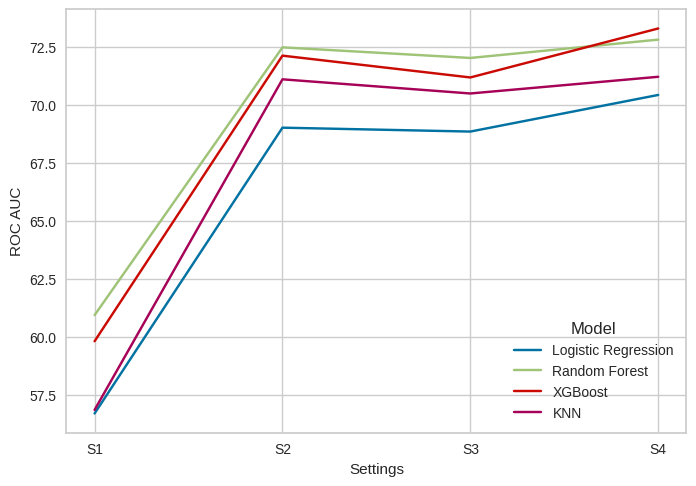

In [15]:
sns.lineplot(data=metrics_cost_deviation, x='stage', y='roc_auc', hue='model')
# plt.title('Metric: ROC AUC')
plt.xlabel('Settings')
plt.ylabel('ROC AUC')
plt.legend(title='Model', loc='lower right')
plt.show()

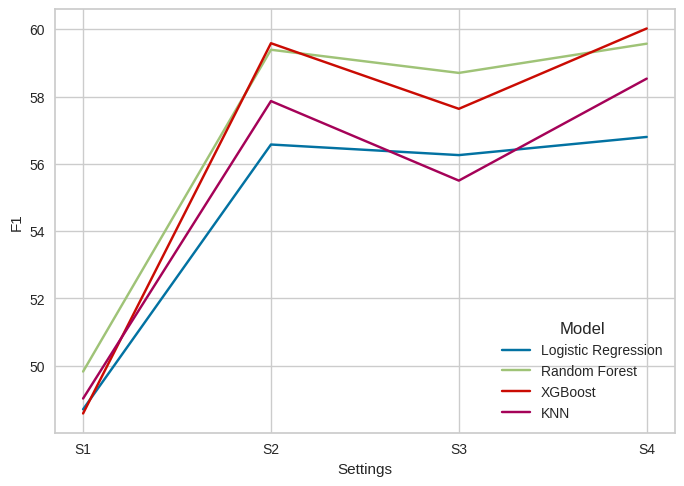

In [16]:
sns.lineplot(data=metrics_cost_deviation, x='stage', y='f1', hue='model')
# plt.title('Metric: F1')
plt.xlabel('Settings')
plt.ylabel('F1')
plt.legend(title='Model', loc='lower right')
plt.show()

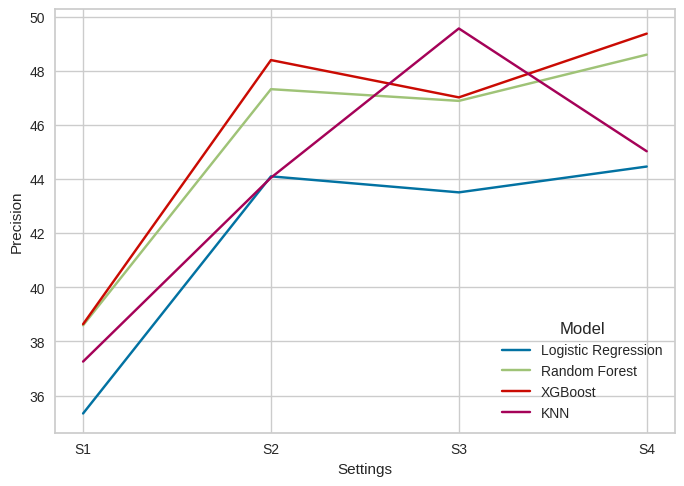

In [17]:
sns.lineplot(data=metrics_cost_deviation, x='stage', y='precision', hue='model')
# plt.title('Metric: Precision')
plt.xlabel('Settings')
plt.ylabel('Precision')
plt.legend(title='Model', loc='lower right')
plt.show()

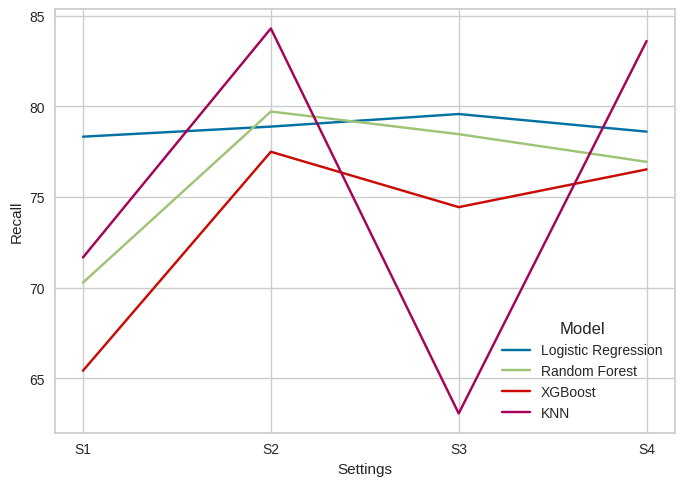

In [18]:
sns.lineplot(data=metrics_cost_deviation, x='stage', y='recall', hue='model')
# plt.title('Metric: Recall')
plt.xlabel('Settings')
plt.ylabel('Recall')
plt.legend(title='Model', loc='lower right')
plt.show()

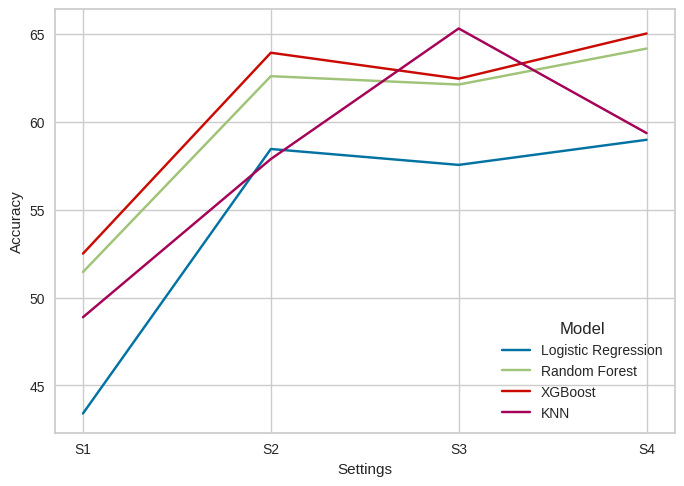

In [19]:
sns.lineplot(data=metrics_cost_deviation, x='stage', y='accuracy', hue='model')
# plt.title('Metric: Accuracy')
plt.xlabel('Settings')
plt.ylabel('Accuracy')
plt.legend(title='Model', loc='lower right')

In [20]:
metrics_cost_deviation.set_index(['model', 'stage']).to_latex(
    index=True,
    float_format=lambda x: "{:.2f}".format(x)
)

'\\begin{tabular}{llrrrrr}\n\\toprule\n &  & accuracy & precision & recall & f1 & roc_auc \\\\\nmodel & stage &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{Logistic Regression} & S1 & 43.40 & 35.34 & 78.33 & 48.70 & 56.70 \\\\\n & S2 & 58.46 & 44.10 & 78.89 & 56.57 & 69.02 \\\\\n & S3 & 57.55 & 43.51 & 79.58 & 56.26 & 68.85 \\\\\n & S4 & 58.98 & 44.46 & 78.61 & 56.80 & 70.43 \\\\\n\\cline{1-7}\n\\multirow[t]{4}{*}{Random Forest} & S1 & 51.45 & 38.60 & 70.28 & 49.83 & 60.94 \\\\\n & S2 & 62.60 & 47.32 & 79.72 & 59.39 & 72.48 \\\\\n & S3 & 62.12 & 46.89 & 78.47 & 58.70 & 72.02 \\\\\n & S4 & 64.17 & 48.60 & 76.94 & 59.57 & 72.81 \\\\\n\\cline{1-7}\n\\multirow[t]{4}{*}{XGBoost} & S1 & 52.50 & 38.64 & 65.42 & 48.58 & 59.82 \\\\\n & S2 & 63.94 & 48.40 & 77.50 & 59.58 & 72.12 \\\\\n & S3 & 62.46 & 47.02 & 74.44 & 57.63 & 71.18 \\\\\n & S4 & 65.03 & 49.37 & 76.53 & 60.02 & 73.29 \\\\\n\\cline{1-7}\n\\multirow[t]{4}{*}{KNN} & S1 & 48.88 & 37.26 & 71.67 & 49.03 & 56.86 \\\\\n & S2 & 57.88 

## Time Deviation Analysis

In [48]:
lr_results_time_deviation = joblib.load('Models/time_deviation_lr_results.joblib')
rf_results_time_deviation = joblib.load('Models/time_deviation_rf_results.joblib')
xgb_results_time_deviation = joblib.load('Models/time_deviation_xgb_results.joblib')
knn_results_time_deviation = joblib.load('Models/time_deviation_knn_results.joblib')
lr_metrics_time_deviation = {}
for i in np.arange(1, len(set_vars)+1):
  lr_metrics_time_deviation[str(i)] = lr_results_time_deviation[f'S{i}']['metrics']
lr_metrics_time_deviation = pd.DataFrame(lr_metrics_time_deviation).T

rf_metrics_time_deviation = {}
for i in np.arange(1, len(set_vars)+1):
  rf_metrics_time_deviation[str(i)] = rf_results_time_deviation[f'S{i}']['metrics']
rf_metrics_time_deviation = pd.DataFrame(rf_metrics_time_deviation).T

xgb_metrics_time_deviation = {}
for i in np.arange(1, len(set_vars)+1):
  xgb_metrics_time_deviation[str(i)] = xgb_results_time_deviation[f'S{i}']['metrics']
xgb_metrics_time_deviation = pd.DataFrame(xgb_metrics_time_deviation).T

knn_metrics_time_deviation = {}
for i in np.arange(1, len(set_vars)+1):
  knn_metrics_time_deviation[str(i)] = knn_results_time_deviation[f'S{i}']['metrics']
knn_metrics_time_deviation = pd.DataFrame(knn_metrics_time_deviation).T

metrics_time_deviation = pd.concat([lr_metrics_time_deviation, rf_metrics_time_deviation, xgb_metrics_time_deviation, knn_metrics_time_deviation], axis=0)
for i in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
  metrics_time_deviation[i] = pd.to_numeric(metrics_time_deviation[i]*100, errors='coerce')
metrics_time_deviation

,model,stage,accuracy,precision,recall,f1,roc_auc
1,Logistic Regression,S1,55.264412,50.186104,85.608466,63.277278,60.542580
2,Logistic Regression,S2,66.698428,60.318792,76.084656,67.290594,74.454440
3,Logistic Regression,S3,67.031920,60.603521,76.507937,67.633302,74.891933
4,Logistic Regression,S4,67.079562,60.392799,78.095238,68.112598,75.428095
1,Random Forest,S1,54.359219,49.624928,91.005291,64.227035,62.918718
2,Random Forest,S2,68.365889,62.761126,73.121693,67.546432,76.761437
3,Random Forest,S3,69.699857,63.540754,76.719577,69.511026,77.826470
4,Random Forest,S4,68.794664,62.652705,75.978836,68.675275,77.524415
1,XGBoost,S1,55.597904,50.426789,81.269841,62.236629,62.781125
2,XGBoost,S2,68.365889,62.691960,73.439153,67.641326,76.123215


In [22]:
metrics_time_deviation.describe()

,accuracy,precision,recall,f1,roc_auc
count,16.000000,16.000000,16.000000,16.000000,16.000000
mean,64.896975,59.006511,77.791005,66.800028,72.397825
std,6.000040,5.479925,4.754276,2.904392,6.804544
min,54.359219,49.624928,73.121693,59.482393,58.729975
25%,63.923297,57.845791,74.894180,66.524704,71.242423
50%,68.032396,61.417009,76.296296,67.686942,75.526854
75%,68.592187,62.662519,78.518519,68.631214,76.915227
max,69.699857,63.540754,91.005291,69.511026,77.826470


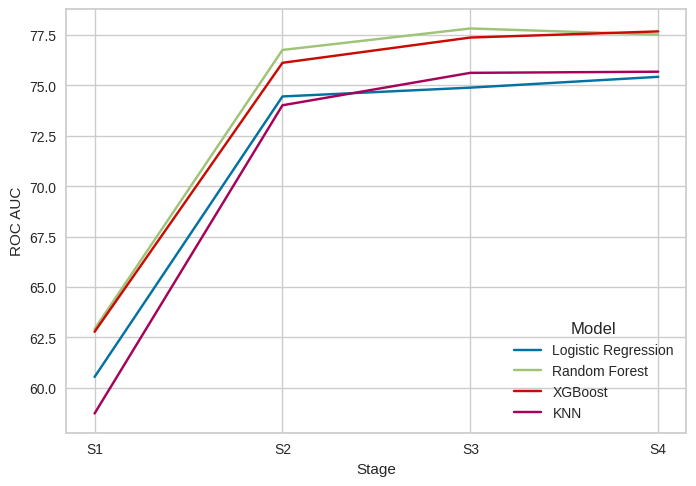

In [23]:
sns.lineplot(data=metrics_time_deviation, x='stage', y='roc_auc', hue='model')
#plt.title('Metric: ROC AUC')
plt.xlabel('Stage')
plt.ylabel('ROC AUC')
plt.legend(title='Model', loc='lower right')
plt.show()

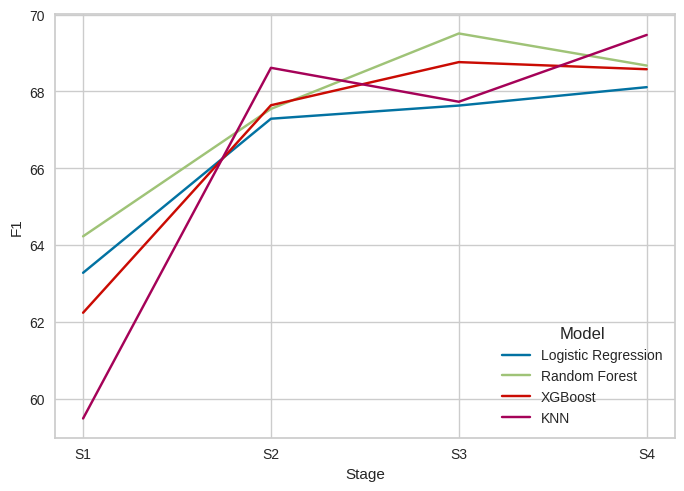

In [24]:
sns.lineplot(data=metrics_time_deviation, x='stage', y='f1', hue='model')
#plt.title('Metric: F1')
plt.xlabel('Stage')
plt.ylabel('F1')
plt.legend(title='Model', loc='lower right')
plt.show()

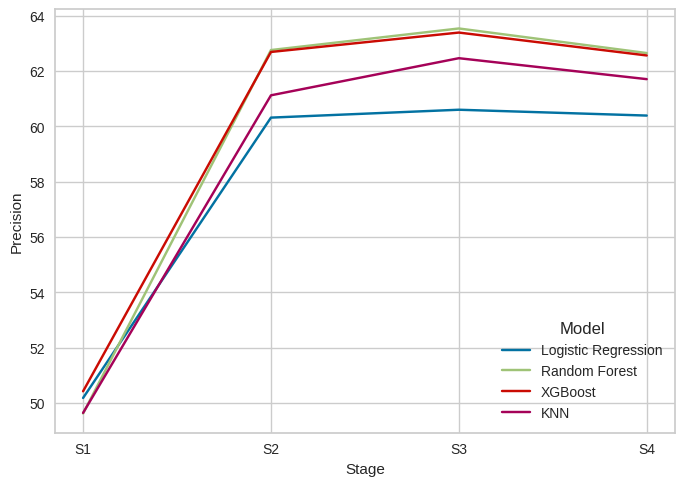

In [25]:
sns.lineplot(data=metrics_time_deviation, x='stage', y='precision', hue='model')
#plt.title('Metric: Precision')
plt.xlabel('Stage')
plt.ylabel('Precision')
plt.legend(title='Model', loc='lower right')
plt.show()

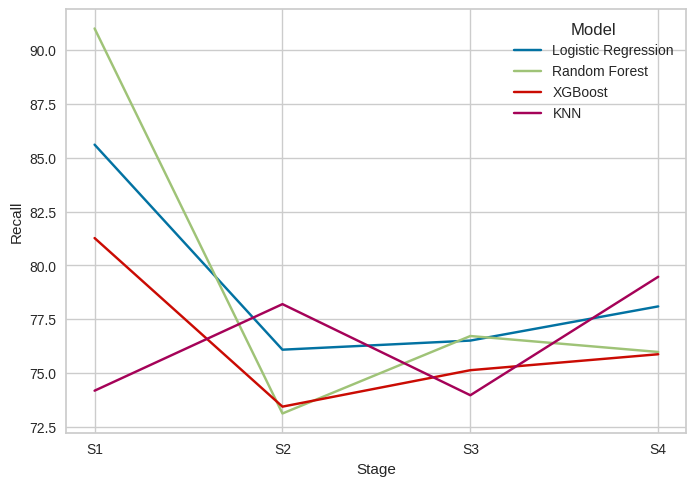

In [26]:
sns.lineplot(data=metrics_time_deviation, x='stage', y='recall', hue='model')
#plt.title('Metric: Recall')
plt.xlabel('Stage')
plt.ylabel('Recall')
plt.legend(title='Model', loc='upper right')
plt.show()

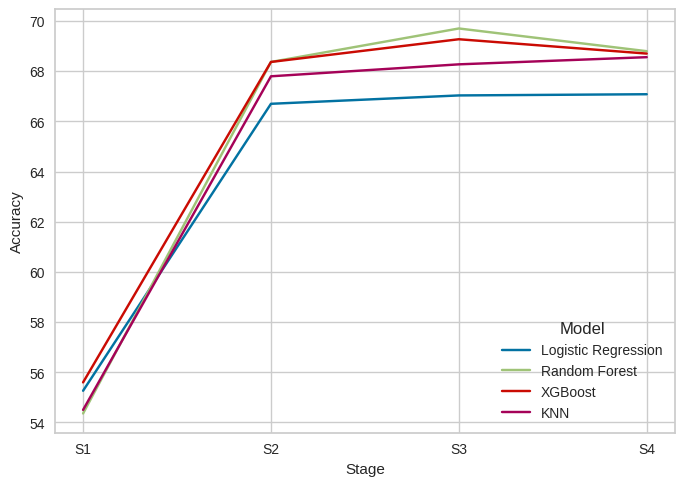

In [27]:
sns.lineplot(data=metrics_time_deviation, x='stage', y='accuracy', hue='model')
#plt.title('Metric: Accuracy')
plt.xlabel('Stage')
plt.ylabel('Accuracy')
plt.legend(title='Model', loc='lower right')
plt.show()

In [28]:
metrics_time_deviation.set_index(['model','stage']).to_latex(
    index=True,
    float_format=lambda x: "{:.2f}".format(x)
)

'\\begin{tabular}{llrrrrr}\n\\toprule\n &  & accuracy & precision & recall & f1 & roc_auc \\\\\nmodel & stage &  &  &  &  &  \\\\\n\\midrule\n\\multirow[t]{4}{*}{Logistic Regression} & S1 & 55.26 & 50.19 & 85.61 & 63.28 & 60.54 \\\\\n & S2 & 66.70 & 60.32 & 76.08 & 67.29 & 74.45 \\\\\n & S3 & 67.03 & 60.60 & 76.51 & 67.63 & 74.89 \\\\\n & S4 & 67.08 & 60.39 & 78.10 & 68.11 & 75.43 \\\\\n\\cline{1-7}\n\\multirow[t]{4}{*}{Random Forest} & S1 & 54.36 & 49.62 & 91.01 & 64.23 & 62.92 \\\\\n & S2 & 68.37 & 62.76 & 73.12 & 67.55 & 76.76 \\\\\n & S3 & 69.70 & 63.54 & 76.72 & 69.51 & 77.83 \\\\\n & S4 & 68.79 & 62.65 & 75.98 & 68.68 & 77.52 \\\\\n\\cline{1-7}\n\\multirow[t]{4}{*}{XGBoost} & S1 & 55.60 & 50.43 & 81.27 & 62.24 & 62.78 \\\\\n & S2 & 68.37 & 62.69 & 73.44 & 67.64 & 76.12 \\\\\n & S3 & 69.27 & 63.39 & 75.13 & 68.77 & 77.38 \\\\\n & S4 & 68.70 & 62.57 & 75.87 & 68.58 & 77.68 \\\\\n\\cline{1-7}\n\\multirow[t]{4}{*}{KNN} & S1 & 54.50 & 49.65 & 74.18 & 59.48 & 58.73 \\\\\n & S2 & 67.79 

## Análisis de Variables para desviaciones en costo

In [29]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.impute import SimpleImputer

### Preparación de los datos

In [50]:
X = df[vars_s4].copy()
y = df['haveCostDeviation(G5)'].copy()

In [51]:
# Convertir solo las columnas object en columnas categoricas
# for i in X.columns:
#  if X[i].dtype == 'object':
#    print(i)
#    X[i] = X[i].astype('category')

In [52]:
X_num = X.select_dtypes(include=['int64', 'float64'])
X_cat = X.select_dtypes(include=['object'])

In [53]:
num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

In [54]:
X_num = pd.DataFrame(num_imputer.fit_transform(X_num), columns=X_num.columns)
X_num

,contractValueMw(G1),contractDurationDays(G1),projectIntensityMw(G1),prebidValueMw(G1),bidContractRatio(G1),contractMonthSigned(G1),contractMonthStart(G1),electoralYear(G1),preelectoralYear(G1),histHHINumProject(G2),histHHIValueProject(G2),histPctDesvTiempo(G2),histPctDesvCost(G2),histPctDesvTimeAndCost(G2),histPctDirectContracts(G2),histPctTenderContracts(G2),totalCumContracts(G2),histAvgProjectIntensity(G2),histAvgBidRatio(G2),histAvgTimeDeviation(G2),histAvgCostDeviation(G2),histAvgContractValue(G2),histAvgContractDuration(G2),penaltiesAccumulated(G2),penaltiesRecent(G2),isBusinessGroup(G3),managementComponent(G4),openGovernmentTransparency(G4),gdp(G4),gdpPerCapita(G4),gdpByEconomicActivityConstruction(G4)
0,8565.518207,436.0,19.645684,8592.597712,0.996849,3.0,4.0,1.0,0.0,10000.000000,10000.000000,0.000000,0.000000,0.000000,0.0,100.0,4.0,13.214481,0.999072,0.000000,0.000000,396.434431,30.000000,0.0,0.0,1.0,63.270000,92.590000,116555.350,2.526253e+07,3678.29
1,2768.043340,180.0,15.378019,2769.087163,0.999623,9.0,11.0,0.0,0.0,2000.000000,4242.168026,0.000000,5.882353,0.000000,0.0,100.0,17.0,7.982555,0.988179,0.000000,0.000852,1223.930186,133.235294,1.0,0.0,1.0,56.010000,88.780000,8895.790,2.891737e+07,213.80
2,2228.382070,180.0,12.379900,2285.238805,0.975120,5.0,5.0,0.0,0.0,10000.000000,10000.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,0.0,0.0,79.370000,98.700000,26040.190,1.910734e+07,1937.49
3,1129.334136,300.0,3.764447,1180.809984,0.956406,8.0,11.0,1.0,0.0,6666.666667,6791.560635,0.000000,0.000000,0.000000,0.0,100.0,1.0,5.810628,0.973947,0.000000,0.000000,1220.231857,210.000000,0.0,0.0,1.0,42.130000,11.110000,9794.200,1.012956e+07,831.05
4,1855.217582,73.0,25.413939,1857.768371,0.998627,10.0,11.0,0.0,1.0,5000.000000,6228.946345,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,60.397143,88.890000,4170.650,1.008162e+07,318.92
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6989,1487.546520,120.0,12.396221,1487.546956,1.000000,5.0,5.0,0.0,0.0,5200.000000,5540.804872,20.000000,40.000000,20.000000,0.0,100.0,5.0,3.638859,0.999140,0.100000,0.109602,326.951099,84.000000,0.0,0.0,0.0,48.844286,71.684286,104238.980,1.677290e+07,7946.79
6990,6432.480057,270.0,23.824000,6440.563468,0.998745,8.0,8.0,0.0,0.0,588.235294,1795.891445,65.217391,47.826087,47.826087,0.0,100.0,23.0,17.060551,0.997278,0.560697,0.162725,4475.210776,220.434783,0.0,0.0,1.0,50.991429,85.827143,698.185,7.616826e+06,94.08
6991,1503.617334,120.0,12.530144,1505.012884,0.999073,8.0,8.0,0.0,0.0,1111.111111,1793.170753,11.111111,11.111111,11.111111,0.0,100.0,9.0,12.128587,0.998596,0.037037,0.013053,1618.667610,133.333333,0.0,0.0,1.0,58.284286,85.868571,37073.765,3.876559e+07,2275.22
6992,10287.899685,300.0,34.292999,10297.507154,0.999067,7.0,8.0,0.0,0.0,769.230769,2355.784683,23.076923,23.076923,23.076923,0.0,100.0,13.0,16.615762,0.999502,0.111722,0.081288,3169.089584,155.769231,5.0,1.0,1.0,51.757143,77.877143,4963.925,2.005024e+07,359.40


In [55]:
X_scaler = StandardScaler().fit(X_num)
X_num_scaled = pd.DataFrame(X_scaler.transform(X_num), columns=X_num.columns)
X_num_scaled

,contractValueMw(G1),contractDurationDays(G1),projectIntensityMw(G1),prebidValueMw(G1),bidContractRatio(G1),contractMonthSigned(G1),contractMonthStart(G1),electoralYear(G1),preelectoralYear(G1),histHHINumProject(G2),histHHIValueProject(G2),histPctDesvTiempo(G2),histPctDesvCost(G2),histPctDesvTimeAndCost(G2),histPctDirectContracts(G2),histPctTenderContracts(G2),totalCumContracts(G2),histAvgProjectIntensity(G2),histAvgBidRatio(G2),histAvgTimeDeviation(G2),histAvgCostDeviation(G2),histAvgContractValue(G2),histAvgContractDuration(G2),penaltiesAccumulated(G2),penaltiesRecent(G2),isBusinessGroup(G3),managementComponent(G4),openGovernmentTransparency(G4),gdp(G4),gdpPerCapita(G4),gdpByEconomicActivityConstruction(G4)
0,1.098352,2.618738,-0.057513,1.089274,0.147968,-1.310658,-0.898528,1.398586,-0.47827,2.035300,1.785244,-1.195163,-1.077185,-0.909208,-0.177333,0.316551,-0.653641,0.210808,0.331682,-0.944052,-0.882181,-0.690776,-1.352093,-0.218332,-0.342682,0.755165,0.202351,0.481292,1.815562,0.503619,0.246821
1,-0.249327,-0.025405,-0.354511,-0.254183,0.257093,0.419678,1.091706,-0.715008,-0.47827,-0.471903,-0.099161,-1.195163,-0.812884,-0.909208,-0.177333,0.316551,-0.210008,-0.395844,0.293658,-0.944052,-0.869826,-0.316545,0.255473,-0.015971,-0.342682,0.755165,-0.401332,0.264996,-0.825647,0.888955,-0.989091
2,-0.374777,-0.025405,-0.563158,-0.365805,-0.706631,-0.733879,-0.614209,-0.715008,-0.47827,2.035300,1.785244,-1.195163,-1.077185,-0.909208,-0.177333,-3.159049,-0.790143,-1.321435,-3.155817,-0.944052,-0.882181,-0.870061,-1.819249,-0.015971,-0.342682,-1.324214,1.541095,0.828159,-0.405044,-0.145333,-0.374187
3,-0.630261,1.214037,-1.162730,-0.620592,-1.442654,0.131288,1.091706,1.398586,-0.47827,0.990632,0.735196,-1.195163,-1.077185,-0.909208,-0.177333,0.316551,-0.756017,-0.647683,0.243977,-0.944052,-0.882181,-0.318218,1.450843,-0.218332,-0.342682,0.755165,-1.555479,-4.144365,-0.803606,-1.091875,-0.768895
4,-0.461522,-1.130575,0.343915,-0.464420,0.217916,0.708067,1.091706,-0.715008,2.09087,0.468298,0.551065,-1.195163,-1.077185,-0.909208,-0.177333,-3.159049,-0.790143,-1.321435,-3.155817,-0.944052,-0.882181,-0.870061,-1.819249,-0.218332,-0.342682,-1.324214,-0.036533,0.271241,-0.941569,-1.096929,-0.951591
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6989,-0.546991,-0.645126,-0.562022,-0.549829,0.271907,-0.733879,-0.614209,-0.715008,-0.47827,0.530978,0.325853,-0.417282,0.720058,0.163551,-0.177333,0.316551,-0.619515,-0.899503,0.331919,-0.444482,0.707713,-0.722199,-0.511212,-0.218332,-0.342682,-1.324214,-0.997174,-0.705535,1.513405,-0.391457,1.769553
6990,0.602507,0.904176,0.233267,0.592810,0.222555,0.131288,0.238748,-0.715008,-0.47827,-0.914350,-0.899771,1.341406,1.071693,1.656086,-0.177333,0.316551,-0.005255,0.656766,0.325419,1.857021,1.478303,1.153828,1.613332,-0.218332,-0.342682,0.755165,-0.818635,0.097361,-1.026758,-1.356796,-1.031800
6991,-0.543255,-0.645126,-0.552702,-0.545799,0.235448,0.131288,0.238748,-0.715008,-0.47827,-0.750481,-0.900661,-0.763007,-0.577951,-0.313231,-0.177333,0.316551,-0.483013,0.084896,0.330020,-0.759026,-0.692827,-0.138028,0.257000,-0.218332,-0.342682,0.755165,-0.212221,0.099713,-0.134357,1.927268,-0.253706
6992,1.498737,1.214037,0.961831,1.482589,0.235223,-0.157101,0.238748,-0.715008,-0.47827,-0.857626,-0.716531,-0.297608,-0.040314,0.328591,-0.177333,0.316551,-0.346511,0.605192,0.333183,-0.385924,0.296977,0.563142,0.606369,0.793471,2.918158,0.755165,-0.754965,-0.353964,-0.922107,-0.045921,-0.937150


In [56]:
X_enc = OneHotEncoder(handle_unknown='ignore', drop='if_binary')
X_cat_enc = pd.DataFrame(X_enc.fit_transform(X_cat).toarray(), columns=X_enc.get_feature_names_out())
X_cat_enc

,workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,databaseSource(G1)_SECOPII,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,ownerDepartment(G2)_AMAZONAS,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NO DEFINIDO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,"ownerDepartment(G2)_SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerRegion(G2)_AMAZONIA,ownerRegion(G2)_ANDINA,ownerRegion(G2)_CARIBE,ownerRegion(G2)_ORINOQUIA,ownerRegion(G2)_OTHER,ownerRegion(G2)_PACIFICA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,"contractorDepartment(G3)_SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,contractorRegion(G3)_AMAZONIA,contractorRegion(G3)_ANDINA,contractorRegion(G3)_CARIBE,contractorRegion(G3)_ORINOQUIA,contractorRegion(G3)_OTHER,contractorRegion(G3)_PACIFICA
0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0

In [57]:
# concatenar x_train_num_scaled y X_train_cat_enc
X = pd.concat([X_num, X_cat_enc], axis=1)
X

,contractValueMw(G1),contractDurationDays(G1),projectIntensityMw(G1),prebidValueMw(G1),bidContractRatio(G1),contractMonthSigned(G1),contractMonthStart(G1),electoralYear(G1),preelectoralYear(G1),histHHINumProject(G2),histHHIValueProject(G2),histPctDesvTiempo(G2),histPctDesvCost(G2),histPctDesvTimeAndCost(G2),histPctDirectContracts(G2),histPctTenderContracts(G2),totalCumContracts(G2),histAvgProjectIntensity(G2),histAvgBidRatio(G2),histAvgTimeDeviation(G2),histAvgCostDeviation(G2),histAvgContractValue(G2),histAvgContractDuration(G2),penaltiesAccumulated(G2),penaltiesRecent(G2),isBusinessGroup(G3),managementComponent(G4),openGovernmentTransparency(G4),gdp(G4),gdpPerCapita(G4),gdpByEconomicActivityConstruction(G4),workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,databaseSource(G1)_SECOPII,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,ownerDepartment(G2)_AMAZONAS,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NO DEFINIDO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,"ownerDepartment(G2)_SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerRegion(G2)_AMAZONIA,ownerRegion(G2)_ANDINA,ownerRegion(G2)_CARIBE,ownerRegion(G2)_ORINOQUIA,ownerRegion(G2)_OTHER,ownerRegion(G2)_PACIFICA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,"contractorDepartment(G3)_SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,contractorRegion(G3)_AMAZONIA,contractorRegion(G3)_ANDINA,contractorRegion(G3)_CARIBE,contractorRegion(G3)_ORINOQUIA,contractorRegion(G3)_OTHER,contractorRegion(G3)_PACIFICA
0,8565.518207,436.0,19.645684,8592.597712,0.996849,3.0,4.0,1.0,0.0,10000.000000,10000.000000,0.000000,0.000000,0.000000,0.0,100.0,4.0,13.214481,0.999072,0.000000,0.000000,396.434431,30.000000,0.0,0.0,1.0,63.270000,92.590000,116555.350,2.526253e+07,3678.29,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0

### XGBoost

In [56]:
xgb_results['S4']['best_params']

{'max_depth': 7,
 'learning_rate': 0.05894752270510293,
 'n_estimators': 138,
 'min_child_weight': 4,
 'subsample': 0.868279172624095,
 'colsample_bytree': 0.946550761466555,
 'gamma': 0.6281779508748377}

In [57]:
xgb_model_cost = XGBClassifier(**xgb_results['S4']['best_params'])
xgb_model_cost.fit(X, y)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.946550761466555, device=None,
              early_stopping_rounds=None, enable_categorical=False,
              eval_metric=None, feature_types=None, gamma=0.6281779508748377,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05894752270510293,
              max_bin=None, max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=7, max_leaves=None,
              min_child_weight=4, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=138, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [35]:
shap.initjs()  # Esto debería cargar JavaScript

In [79]:
explainer_xgb_cost = shap.TreeExplainer(xgb_model_cost)
shap_values_xgb_model = explainer_xgb_cost.shap_values(X)

In [80]:
# Gráfico de importancia de variables
shap.force_plot(explainer_xgb_cost.expected_value, shap_values_xgb_model[0, :], X.iloc[0, :])

In [38]:
y

,haveCostDeviation(G5)
0,1
1,0
2,0
3,1
4,0
...,...
6989,0
6990,1
6991,0
6992,0


In [126]:
explainer_xgb_cost.expected_value

np.float32(-0.65998816)

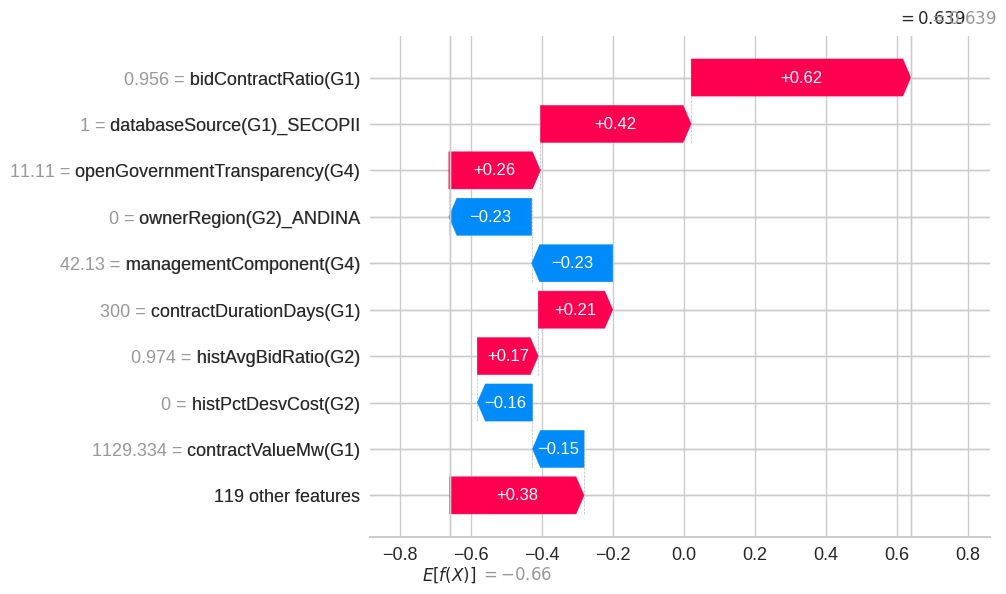

In [81]:
shap.plots.waterfall(shap.Explanation(values=shap_values_xgb_model[3],
                                     base_values=explainer_xgb_cost.expected_value,
                                     data=X.iloc[3]))

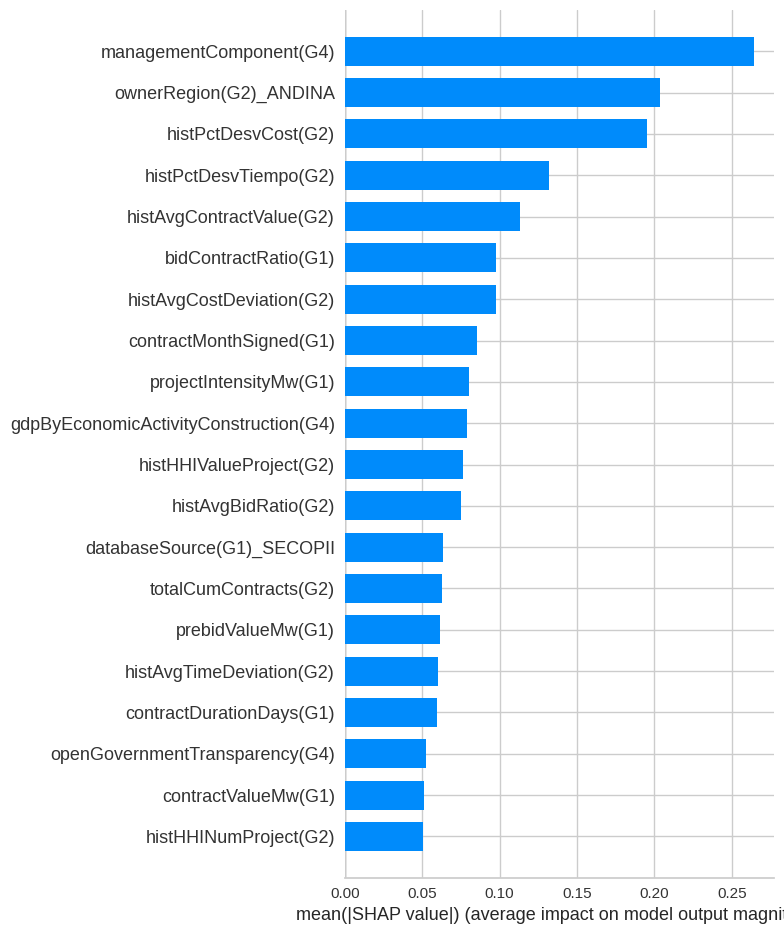

In [82]:
shap.summary_plot(shap_values_xgb_model, X, plot_type="bar")

In [144]:
shap_values_xgb_model.shape

(6994, 128)

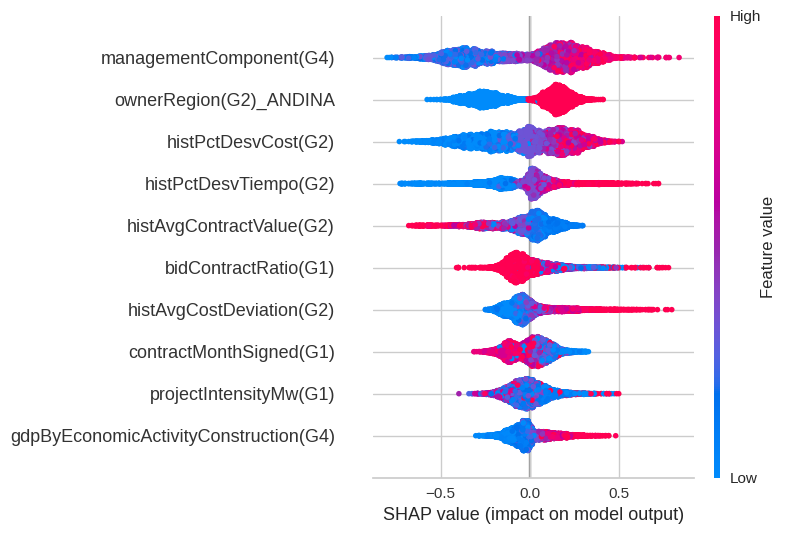

In [83]:
# Shap summary plot
shap.summary_plot(shap_values_xgb_model, X, max_display=10)

### Random Forest

In [66]:
# drop 'max_features_type' from dic
rf_results['S4']['best_params']

{'max_depth': 25,
 'n_estimators': 279,
 'min_samples_split': 4,
 'min_samples_leaf': 2,
 'max_features': 'log2',
 'bootstrap': True}

In [68]:
rf_model_cost = RandomForestClassifier()
rf_model_cost.set_params(**rf_results['S4']['best_params'])
rf_model_cost.fit(X, y)

RandomForestClassifier(max_depth=25, max_features='log2', min_samples_leaf=2,
                       min_samples_split=4, n_estimators=279)

In [69]:
# Construir el explainer
explainer_rf_cost = shap.TreeExplainer(rf_model_cost)
# Calcular los valores SHAP
shap_values_rf_model = explainer_rf_cost.shap_values(X)

In [137]:
rf_pred_cost = rf_model_cost.predict(X)
rf_pred_cost

array([1, 0, 1, ..., 0, 0, 1])

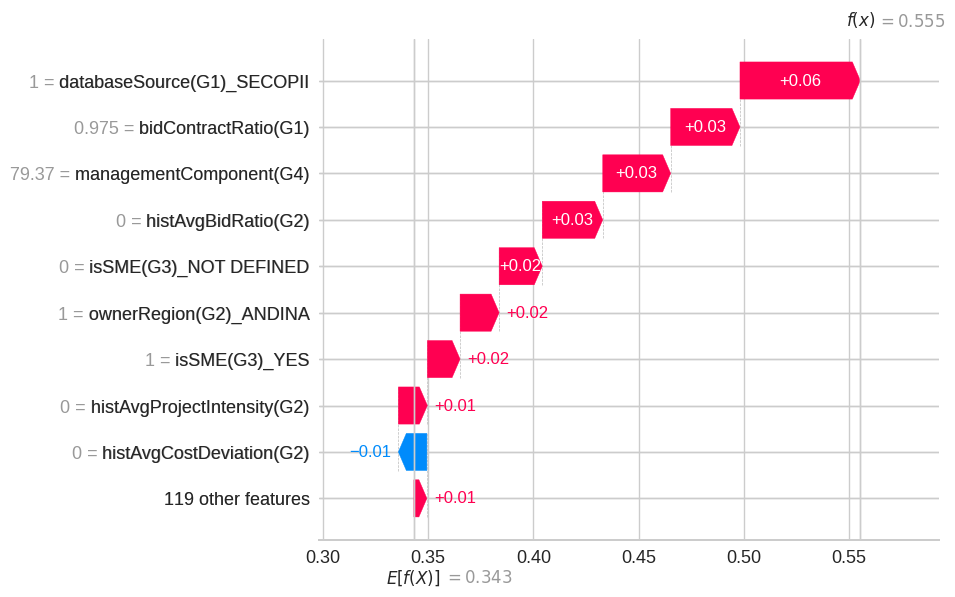

In [178]:
# Waterfall plot for instance 3
y_instance = 2
shap.plots.waterfall(shap.Explanation(shap_values_rf_model[y_instance, :, 1],
                                     base_values=explainer_rf_cost.expected_value[1],
                                     data=X.iloc[y_instance]))

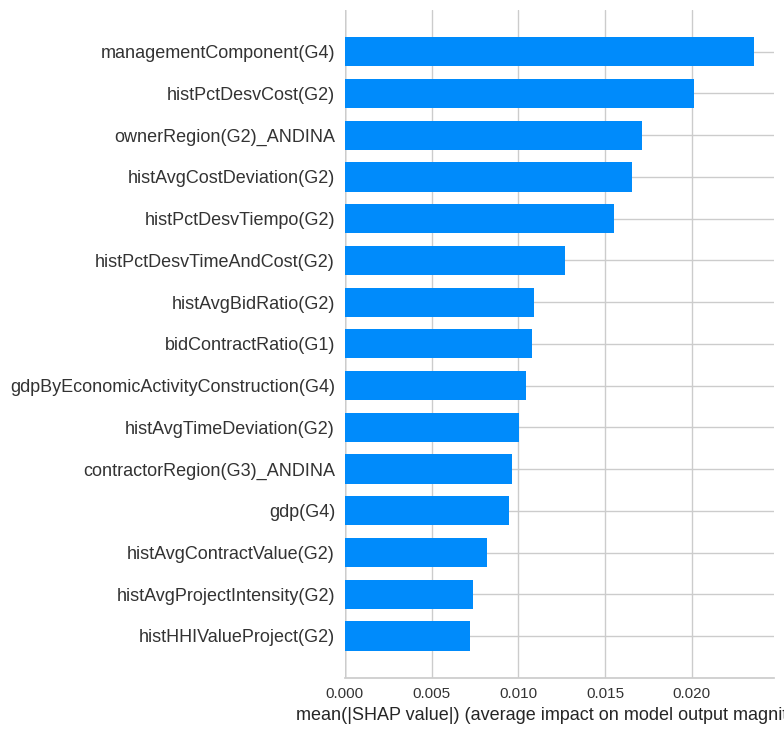

In [181]:
shap.summary_plot(shap_values_rf_model[:, :, 1], X, plot_type="bar", max_display=15)

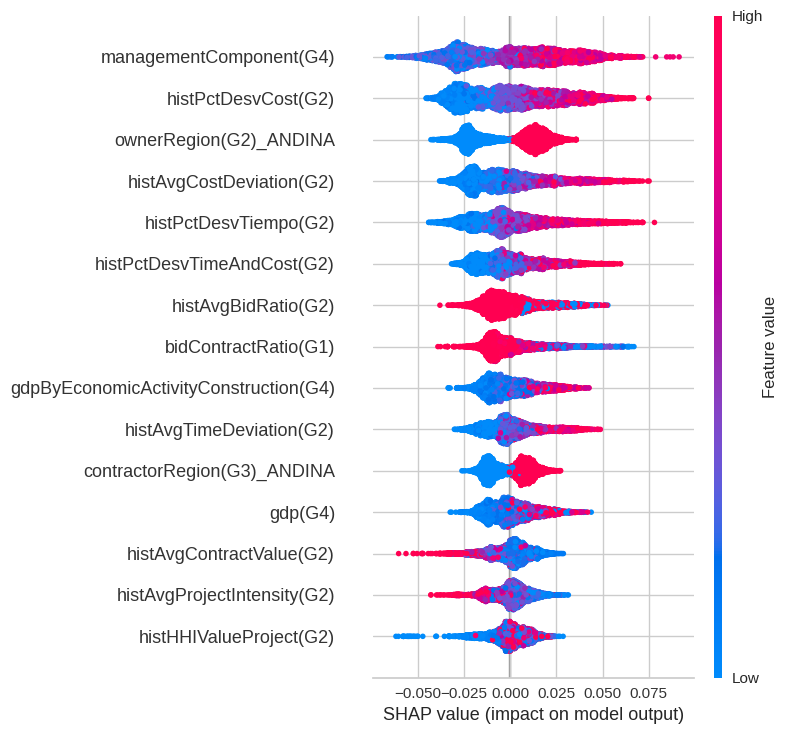

In [180]:
# Shap summary plot
shap.summary_plot(shap_values_rf_model[:, :, 1], X, max_display=15)

### Regresión Logística

In [58]:
# concatenar x_train_num_scaled y X_train_cat_enc
X_std = pd.concat([X_num_scaled, X_cat_enc], axis=1)
X_std

,contractValueMw(G1),contractDurationDays(G1),projectIntensityMw(G1),prebidValueMw(G1),bidContractRatio(G1),contractMonthSigned(G1),contractMonthStart(G1),electoralYear(G1),preelectoralYear(G1),histHHINumProject(G2),histHHIValueProject(G2),histPctDesvTiempo(G2),histPctDesvCost(G2),histPctDesvTimeAndCost(G2),histPctDirectContracts(G2),histPctTenderContracts(G2),totalCumContracts(G2),histAvgProjectIntensity(G2),histAvgBidRatio(G2),histAvgTimeDeviation(G2),histAvgCostDeviation(G2),histAvgContractValue(G2),histAvgContractDuration(G2),penaltiesAccumulated(G2),penaltiesRecent(G2),isBusinessGroup(G3),managementComponent(G4),openGovernmentTransparency(G4),gdp(G4),gdpPerCapita(G4),gdpByEconomicActivityConstruction(G4),workCategory(G1)_Construction,workCategory(G1)_Improvement,workCategory(G1)_Others,workCategory(G1)_Rehabilitation,contractMethodType(G1)_CLOSED,contractMethodType(G1)_OPEN,contractMethodType(G1)_OTHER,contractMethodType(G1)_SIMPLIFIED,contractMethodType(G1)_SPECIAL REGIME,databaseSource(G1)_SECOPII,ownerLevel(G2)_AUTONOMOUS CORPORATION,ownerLevel(G2)_NATIONAL,ownerLevel(G2)_TERRITORIAL,ownerDepartment(G2)_AMAZONAS,ownerDepartment(G2)_ANTIOQUIA,ownerDepartment(G2)_ARAUCA,ownerDepartment(G2)_ATLANTICO,ownerDepartment(G2)_BOGOTA,ownerDepartment(G2)_BOLIVAR,ownerDepartment(G2)_BOYACA,ownerDepartment(G2)_CALDAS,ownerDepartment(G2)_CAQUETA,ownerDepartment(G2)_CASANARE,ownerDepartment(G2)_CAUCA,ownerDepartment(G2)_CESAR,ownerDepartment(G2)_CHOCO,ownerDepartment(G2)_CORDOBA,ownerDepartment(G2)_CUNDINAMARCA,ownerDepartment(G2)_GUAINIA,ownerDepartment(G2)_GUAVIARE,ownerDepartment(G2)_HUILA,ownerDepartment(G2)_LA GUAJIRA,ownerDepartment(G2)_MAGDALENA,ownerDepartment(G2)_META,ownerDepartment(G2)_NARINO,ownerDepartment(G2)_NO DEFINIDO,ownerDepartment(G2)_NORTE DE SANTANDER,ownerDepartment(G2)_PUTUMAYO,ownerDepartment(G2)_QUINDIO,ownerDepartment(G2)_RISARALDA,"ownerDepartment(G2)_SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",ownerDepartment(G2)_SANTANDER,ownerDepartment(G2)_SUCRE,ownerDepartment(G2)_TOLIMA,ownerDepartment(G2)_VALLE DEL CAUCA,ownerDepartment(G2)_VAUPES,ownerDepartment(G2)_VICHADA,ownerRegion(G2)_AMAZONIA,ownerRegion(G2)_ANDINA,ownerRegion(G2)_CARIBE,ownerRegion(G2)_ORINOQUIA,ownerRegion(G2)_OTHER,ownerRegion(G2)_PACIFICA,isSME(G3)_NO,isSME(G3)_NOT DEFINED,isSME(G3)_YES,contractorDepartment(G3)_AMAZONAS,contractorDepartment(G3)_ANTIOQUIA,contractorDepartment(G3)_ARAUCA,contractorDepartment(G3)_ATLANTICO,contractorDepartment(G3)_BOGOTA D.C.,contractorDepartment(G3)_BOLIVAR,contractorDepartment(G3)_BOYACA,contractorDepartment(G3)_CALDAS,contractorDepartment(G3)_CAQUETA,contractorDepartment(G3)_CASANARE,contractorDepartment(G3)_CAUCA,contractorDepartment(G3)_CESAR,contractorDepartment(G3)_CHOCO,contractorDepartment(G3)_COLOMBIA,contractorDepartment(G3)_CORDOBA,contractorDepartment(G3)_CUNDINAMARCA,contractorDepartment(G3)_GUAINIA,contractorDepartment(G3)_GUAVIARE,contractorDepartment(G3)_HUILA,contractorDepartment(G3)_LA GUAJIRA,contractorDepartment(G3)_MAGDALENA,contractorDepartment(G3)_META,contractorDepartment(G3)_NARINO,contractorDepartment(G3)_NO DEFINIDO,contractorDepartment(G3)_NORTE DE SANTANDER,contractorDepartment(G3)_PUTUMAYO,contractorDepartment(G3)_QUINDIO,contractorDepartment(G3)_RISARALDA,"contractorDepartment(G3)_SAN ANDRES, PROVIDENCIA Y SANTA CATALINA",contractorDepartment(G3)_SANTANDER,contractorDepartment(G3)_SUCRE,contractorDepartment(G3)_TOLIMA,contractorDepartment(G3)_VALLE DEL CAUCA,contractorDepartment(G3)_VAUPES,contractorDepartment(G3)_VICHADA,contractorRegion(G3)_AMAZONIA,contractorRegion(G3)_ANDINA,contractorRegion(G3)_CARIBE,contractorRegion(G3)_ORINOQUIA,contractorRegion(G3)_OTHER,contractorRegion(G3)_PACIFICA
0,1.098352,2.618738,-0.057513,1.089274,0.147968,-1.310658,-0.898528,1.398586,-0.47827,2.035300,1.785244,-1.195163,-1.077185,-0.909208,-0.177333,0.316551,-0.653641,0.210808,0.331682,-0.944052,-0.882181,-0.690776,-1.352093,-0.218332,-0.342682,0.755165,0.202351,0.481292,1.815562,0.503619,0.246

In [186]:
# Entrenar regresión logistica con los mejores parametros
lr_model_cost = LogisticRegression()
lr_model_cost.set_params(**lr_results['S4']['best_params'])
lr_model_cost.fit(X_std, y)

LogisticRegression(C=0.08641206104534688)

In [187]:
# Explainer para la regresion logistica
explainer_lr_cost = shap.LinearExplainer(lr_model_cost, X_std)
# Calcular los valores SHAP
shap_values_lr_model = explainer_lr_cost.shap_values(X_std)

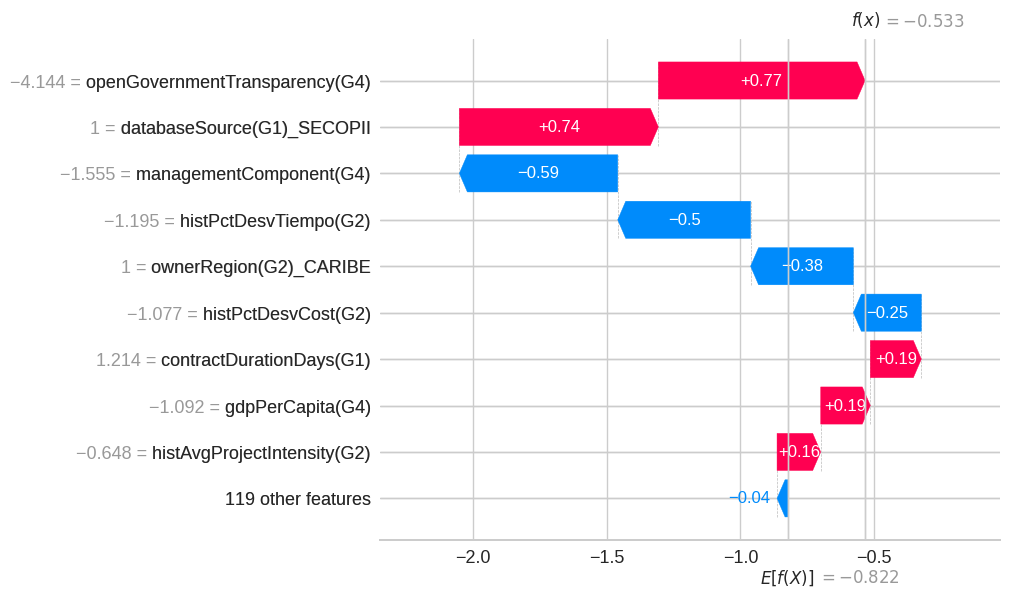

In [188]:
# waterfall plot
shap.plots.waterfall(shap.Explanation(values=shap_values_lr_model[3],
                                     base_values=explainer_lr_cost.expected_value,
                                     data=X_std.iloc[3]))

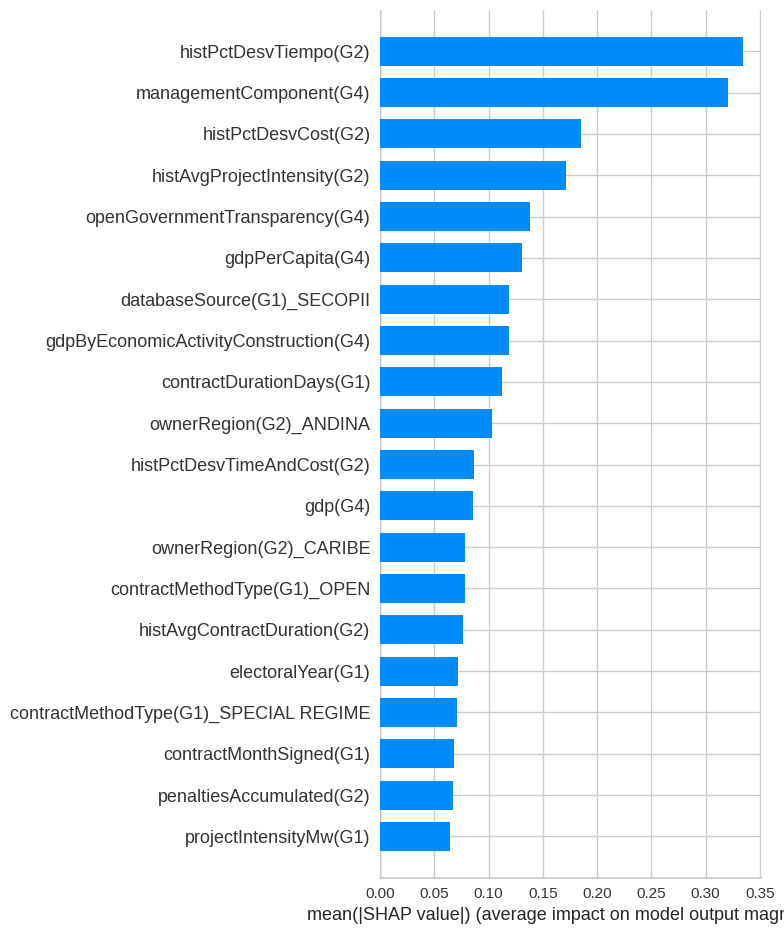

In [189]:
# Summary plot bar
shap.summary_plot(shap_values_lr_model, X_std, plot_type="bar")

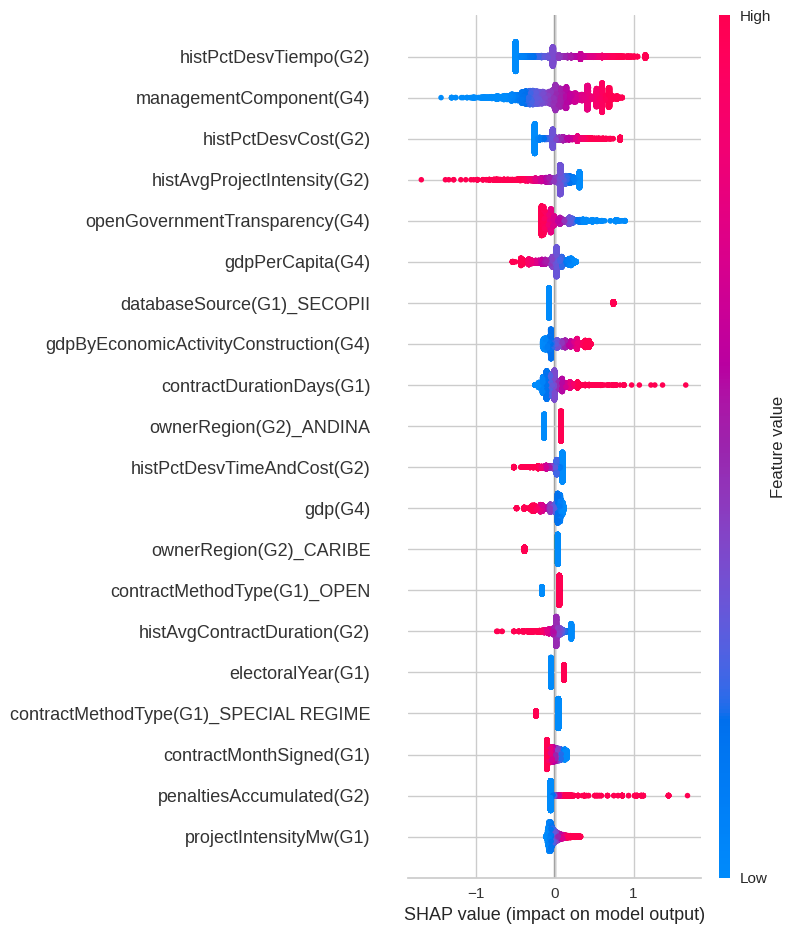

In [190]:
# Summary plot
shap.summary_plot(shap_values_lr_model, X_std)

### KNN

In [72]:
# Train KNN
knn_model_cost = KNeighborsClassifier()
knn_model_cost.set_params(**knn_results['S4']['best_params'])
X_sample = shap.sample(X_std, nsamples=1000)
knn_model_cost.fit(X_sample, y[X_sample.index])

KNeighborsClassifier(metric='manhattan', n_neighbors=37, weights='distance')

In [73]:
# Explainer para KNN
explainer_knn_cost = shap.KernelExplainer(knn_model_cost.predict_proba, X_sample)
# Calcular los valores SHAP
shap_values_knn_model = explainer_knn_cost.shap_values(X_sample)

  0%|          | 0/1000 [00:00<?, ?it/s]

KeyboardInterrupt: 